In [1]:
print('hola')
import matplotlib.pyplot as plt
import numpy as np

hola


# Clasificador Lineal
Se entrenará un clasificador lineal para predecir que tipo de objeto se encuentra en una imagen.  
El set consta de 7000 imagenes de 28x28 pixeles divididas en 10 categorías.

In [ ]:
from keras.datasets import mnist, fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data() #datos del dataset de entrnamiento y testeo

In [3]:
print("X_train shape:", X_train.shape)  # matriz de 60000x28x28 Los elementos de la matriz son el brillo del pixel
print("y_train shape:", y_train.shape)  # matriz de 60000x1 los elementos de la matriz son el número asociado a cada categoría
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("X_train dtype:",X_train.dtype)
print("y_train dtype:",y_train.dtype)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
X_train dtype: uint8
y_train dtype: uint8


otra forma de pensar la forma de los datos en lugar de matrices son mamushkas, para acceder a lo que está adentro tenemos que ir abriéndolas.

a[0] accede al primer elemento de los 60000 elementos que contiene a

a[0][0] accede al primer elemento de los 28 elementos del primer elemento de los 60000 elementos que contiene a

a[0][0][0] accede al primer elemento de los 28 elementos del primer elemento de los 28 elementos del primer elemento de los 60000 elementos

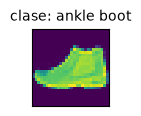

In [4]:
fig= plt.figure(figsize=(1,1))
j= np.random.randint(0, len(X_train)) 
plt.imshow(X_train[j], interpolation= 'none')  #cmap='gray' por defecto matplotlib pone otro mapa de color verde-violeta pero el dataset solo tiene info del brillo de los pixeles
plt.title(f'clase: {features[y_train[j]]}',  fontsize=10)
plt.xticks([])
plt.yticks([])
plt.show()

Preprocesamiento de los datos

In [5]:
# se pasa de la matriz a un vector de 784 (28x28) elementos por cada imagen
X_train= X_train.reshape(60000,-1)
X_test= X_test.reshape(10000,-1)

X_train = X_train.astype('float32') # transformamos el tipo de datos a "float32"
X_test = X_test.astype('float32') # transformamos el tipo de datos a "float32"

# normalizamos por el maximo valor que pueden tener los pixels para que los valores queden entre 0 y 1
X_train = X_train/255.0
X_test = X_test/255.0

# print the final input shape ready for training
print("Matriz de entrenamiento shape", X_train.shape)
print("Matriz de testeo shape", X_test.shape)

Matriz de entrenamiento shape (60000, 784)
Matriz de testeo shape (10000, 784)


Observación de y

In [6]:
values, counts= np.unique(y_train, return_counts=True)
print('y_train:')
print('puede tomar los valores:', values)
print('cantidad de elementos de cada valor (categoría):', counts)

values,counts = np.unique(y_test, return_counts=True)
print("y_test")
print("Values:", values)
print("Counts:", counts)

y_train:
puede tomar los valores: [0 1 2 3 4 5 6 7 8 9]
cantidad de elementos de cada valor (categoría): [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]
y_test
Values: [0 1 2 3 4 5 6 7 8 9]
Counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


Están balanceados ambos sets

In [7]:
from keras.models import Sequential
from keras.layers import Dense

modelillo = Sequential([Dense(10, activation='softmax')     # Genera las 10 probabilidades finales
])

modelillo.compile(
    loss='sparse_categorical_crossentropy',  # Compatible con etiquetas enteras (0 a 9)
    optimizer='adam',
    metrics=['accuracy']
)

# Ahora el fit corre sin problemas
history = modelillo.fit(
    X_train, y_train,
    batch_size=32,
    epochs=10,
    verbose=1,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7992 - loss: 0.5980 - val_accuracy: 0.8268 - val_loss: 0.5050
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8421 - loss: 0.4609 - val_accuracy: 0.8362 - val_loss: 0.4728
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 998us/step - accuracy: 0.8510 - loss: 0.4344 - val_accuracy: 0.8397 - val_loss: 0.4559
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 950us/step - accuracy: 0.8544 - loss: 0.4210 - val_accuracy: 0.8404 - val_loss: 0.4571
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 972us/step - accuracy: 0.8576 - loss: 0.4127 - val_accuracy: 0.8447 - val_loss: 0.4465
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8589 - loss: 0.4064 - val_accuracy: 0.8392 - val_loss: 0.4578
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 955us/step - accuracy: 0.8612 - loss: 0.4020 - val_accuracy: 0.8440 - val_loss: 0.4541
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 967us/step - accuracy: 0.8622 - loss:

In [8]:
probas= modelillo.predict(X_test[5:6])

print('Shape de la probas:',probas.shape)
print('probas:',probas)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Shape de la probas: (1, 10)
probas: [[4.5041880e-04 9.9911016e-01 1.1691211e-04 1.0209077e-04 2.1089324e-04
  8.2900557e-17 9.3759772e-06 2.9463634e-17 2.0012807e-07 9.8332551e-13]]


In [9]:
clasif_estimada= probas[0].argmax()
clasif_real= y_test[5]

print('clase estimada:', clasif_estimada)
print('clase real:', clasif_real)

clase estimada: 1
clase real: 1


In [10]:
import sklearn.metrics as metrics

y_train_estimado= modelillo.predict(X_train)
y_test_estimado= modelillo.predict(X_test)

train_accuracy= metrics.accuracy_score(y_train_estimado.argmax(axis=1),y_train)
test_accuracy= metrics.accuracy_score(y_test_estimado.argmax(axis=1),y_test)

print('Accuracy de set train:', train_accuracy)
print('Accuracy de set test:', test_accuracy)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step
Accuracy de set train: 0.8386166666666667
Accuracy de set test: 0.8158


[[611   3  16  66   4   0 290   0  10   0]
 [  2 959   5  23   2   0   8   0   1   0]
 [  5   6 714  10  50   0 207   0   8   0]
 [  9  15  14 884   9   0  66   0   3   0]
 [  0   3 168  55 489   0 276   0   9   0]
 [  0   0   0   1   0 897   0  53   6  43]
 [ 49   2  89  46  32   0 769   0  13   0]
 [  0   0   0   0   0  23   0 920   0  57]
 [  2   1   7  10   1   3  29   4 943   0]
 [  0   0   0   0   0   3   2  23   0 972]]


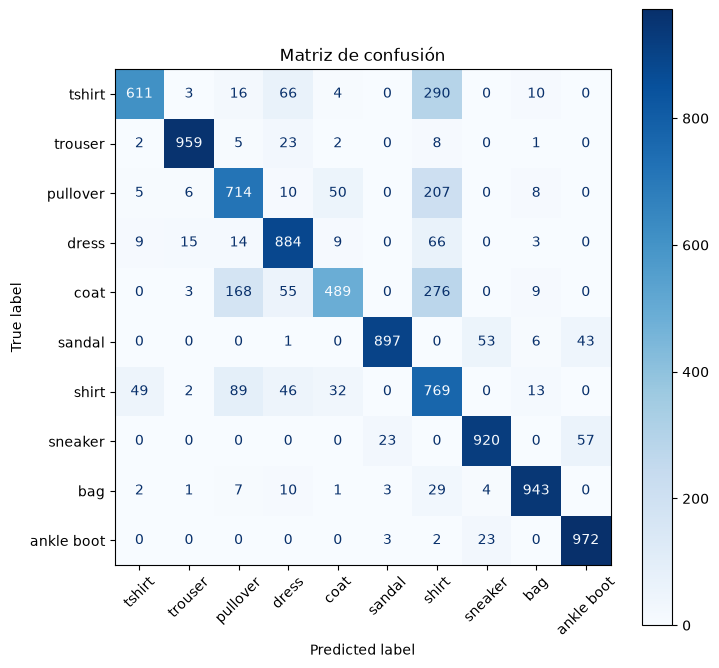

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm= confusion_matrix(y_test,y_test_estimado.argmax(axis=1))
print(cm)

categorías= ['tshirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
# Los indices se corresponden a la categoría que define el clasificador.


fig, ax= plt.subplots(figsize=(8,8))
disp= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= categorías)
disp.plot(cmap='Blues', ax=ax, values_format='d', xticks_rotation=45)
plt.title('Matriz de confusión')
plt.show()

Curioso que no es simétrica. Cuando era t-shirt muchas veces le asignó shirt erroneamente pero cuando era shirt le puso t-shirt erroneamente pocas veces.  
Las filas suman la cant de elementos de esa categoría, como estaban balanceados todos suman 1000.
Las columnas suman la cantidad de veces que el modelo asignó un sample a esa categoría, no suman nada específico, podría dar info de un bias del modelo a priorizar una categoría.

(784, 10)


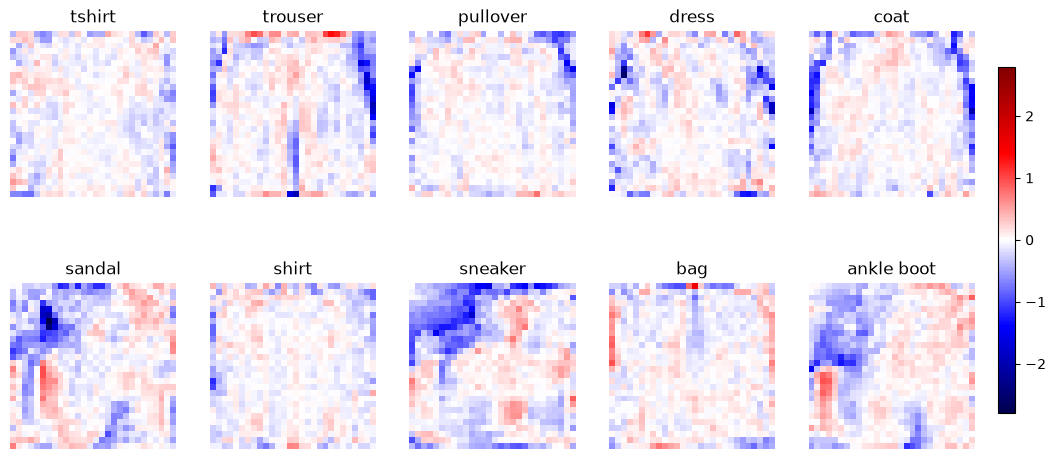

In [26]:
import matplotlib.pyplot as plt
import numpy as np

weigths = modelillo.get_weights()[0] # accedo a la matriz de pesos W de cada perceptrón
print(weigths.shape)

# Rango simétrico común para que el cero quede exactamente en blanco/neutro
vmax = np.max(np.abs(weigths))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    w0 = weigths[:, i]
    im = ax.imshow(w0.reshape(28, 28), cmap='seismic', vmin=-vmax, vmax=vmax)
    ax.set_title(categorías[i])
    ax.axis('off')

# Reserva automáticamente el margen derecho para la barra
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, pad=0.02)
plt.show()

gráfico de la matriz de pesos de cada neurona donde cada neurona representa una caregoría.  
Blanco significa que el brillo de ese pixel no le importa a esa categoría. Es irrelevante para definir si pertenece a esa categoría.  
Azul significa que si ese pixel tiene alto brillo entonces no pertenece a esa categoría.  
Rojo significa que si ese pixel tiene alto brillo entonces pertenece a esa categoría.  
Se ve claramente por qué fallaría el modelo para objetos desplazados o rotados.  
Si tuviera 'silueta' más marcada cada categoría entraría en overfitting. Está bien que no sea un contorno super definido.

# Clasificador basado en instancias KNN

In [12]:
X_train= X_train.reshape(60000,-1)
X_test= X_test.reshape(10000,-1)

X_train= X_train.astype('float32')
X_test= X_test.astype('float32')

X_train= X_train/255
X_test= X_test/255



In [13]:
from sklearn.neighbors import KNeighborsClassifier


acc=[]

clf= KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)

y_estimado= clf.predict(X_train)
accuracy= accuracy_score(y_estimado,y_train)
acc.append(accuracy)
print('Accuracy promedio:', np.mean(accuracy))

NameError: name 'accuracy_score' is not defined